# Gretil IAST Sound Counts
This notebook counts occurrences of:
- `m` + vowel (with whitespace) for each vowel in IAST
- `ṃ` + consonant (with whitespace) for each consonant in IAST
across all Gretil Sanskrit files matching `^sa_.*.txt` using `zoekt`.
The results are saved as `gmsound.csv` (raw counts) and `gmsound_normalized.csv` (column-normalized counts).

In [13]:
import re
import pandas as pd
from glob import glob
import subprocess
import os
try:
    from tqdm import tqdm
except ImportError:
    import sys
    !{sys.executable} -m pip install tqdm
    from tqdm import tqdm

# Define IAST vowels and consonants
# VOWELS = list('aeiouAEIOU') + ['ā', 'ē', 'ī', 'ō', 'ū']
# VOWEL_SET = set(VOWELS)
# ALL_LETTERS = set('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZāēīōūṃṅñṭḍṇśṣḥ')
# CONSONANTS = sorted(list(ALL_LETTERS - VOWEL_SET))

# Patterns
IAST_VOWEL_UNITS = [
    # Vowels
    'a', 'ā', 'i', 'ī', 'u', 'ū', 'ṛ', 'ṝ', 'ḷ', 'ḹ', 'e', 'o', 'ai', 'au'
]

IAST_CONSONANT_UNITS = [
    'k', 'kh', 'g', 'gh', 'ṅ', # Gutturals (ka-varga)
    'c', 'ch', 'j', 'jh', 'ñ', # Palatals (ca-varga)
    'ṭ', 'ṭh', 'ḍ', 'ḍh', 'ṇ', # Retroflexes (ṭa-varga)
    't', 'th', 'd', 'dh', 'n', # Dentals (ta-varga)
    'p', 'ph', 'b', 'bh', 'm', # Labials (pa-varga)
    'y', 'r', 'l', 'v',        # Semivowels
    'ś', 'ṣ', 's',             # Sibilants
    'h',                       # Aspirate
    'ṃ', 'ṁ', 'ḥ'              # Other
]

# VOWELS = list('aeiouAEIOU') + ['ā', 'ē', 'ī', 'ō', 'ū']
# VOWELS_SET = set(
# ALL_LETTERS = set('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZāēīōūṃṅñṭḍṇśṣḥ')
# CONSONANTS = sorted(list(ALL_LETTERS - VOWEL_SET))

VOWELS = IAST_VOWEL_UNITS
CONSONANTS = IAST_CONSONANT_UNITS

In [14]:
import subprocess
import re
from joblib import Memory

DEBUG = not False
def debug_print(*args, **kwargs):
    if DEBUG:
        print(*args, **kwargs)

# Set up persistent disk cache for zoekt_count
memory = Memory(location='.zoekt_cache~', verbose=0)

# Discover Gretil files using zoekt -l with correct pattern
def get_gretil_files():
    cmd = ["zoekt", "-l", "file:\"^gretil/sa_.*txt\""]
    debug_print(f"[DEBUG] Running file discovery command: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    # debug_print(f"[DEBUG] Command output: {result.stdout}")
    files = [line.strip() for line in result.stdout.strip().split('\n') if line.strip()]
    return sorted(files)

gretil_files = get_gretil_files()

@memory.cache
def zoekt_count(pattern, filename):
    """Run zoekt and return the count of matches for a pattern in a file. Emit command for debugging."""
    try:
        cmd = f"zoekt '{pattern}' file:\"{filename}\""
        # debug_print(f"[DEBUG] Running zoekt command: {cmd}")
        result = subprocess.run(cmd, capture_output=True, text=True, shell=True)
        # debug_print(f"[DEBUG] Command output: {result.stdout}")
        count = len(result.stdout.strip().split('\n')) if result.stdout.strip() else 0
        return count
    except Exception as e:
        print(f"Error searching {pattern} in {filename}: {e}")
        return 0

[DEBUG] Running file discovery command: zoekt -l file:"^gretil/sa_.*txt"


In [15]:
# Generate search patterns for m+vowel and ṃ+consonant
m_vowel_patterns = {v: rf"m\s+{v}" for v in VOWELS}
ṃ_consonant_patterns = {c: rf"ṃ\s+{c}" for c in CONSONANTS}

TEST_MODE = not True  # Set to True for testing with a small subset of files
if TEST_MODE :
    # Use a small subset for testing (optional, remove for full run)
    _files = gretil_files[:40]  # First 80 files
    _m_vowel_patterns = dict(list(m_vowel_patterns.items())[:2])  # First 2 vowels
    _ṃ_consonant_patterns = dict(list(ṃ_consonant_patterns.items())[:2])  # First 2 consonants
else:
    _files = gretil_files
    _m_vowel_patterns = m_vowel_patterns
    _ṃ_consonant_patterns = ṃ_consonant_patterns

m_vowel_counts = pd.DataFrame(index=_m_vowel_patterns.keys(), columns=_files).fillna(0)
ṃ_consonant_counts = pd.DataFrame(index=_ṃ_consonant_patterns.keys(), columns=_files).fillna(0)

from tqdm import tqdm

all_patterns = [("m+"+v, pat, m_vowel_counts, v) for v, pat in _m_vowel_patterns.items()] + [("ṃ+"+c, pat, ṃ_consonant_counts, c) for c, pat in _ṃ_consonant_patterns.items()]
        

In [16]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import functools
from tqdm import tqdm

original_zoekt_count = zoekt_count#.__wrapped__

def process_file_for_pattern(file_path, pattern):
    """Process a single file for a single pattern"""
    # return zoekt_count(pattern, file_path)
    return original_zoekt_count(pattern, file_path)

save_all_patterns = all_patterns.copy()  # Save original patterns for later use

#  let all patterns be a slice of itself for debugging
# all_patterns = all_patterns[:2]

num_patterns = len(all_patterns)

# Pattern-level progress bar
with tqdm(total=num_patterns, desc="Processing patterns", unit="pattern") as pbar:
    
    for idx, (pat_name, pat, df, v_or_c) in enumerate(all_patterns):
        pattern_desc = f"Pattern {idx+1}/{num_patterns}: {pat[:50]}..."
        pbar.set_description(pattern_desc)
        
        with ThreadPoolExecutor(max_workers=8) as executor:
            # Submit all file processing tasks
            future_to_file = {
                executor.submit(process_file_for_pattern, f, pat): f 
                for f in _files
            }
            
            completed_files = 0
            total_files = len(_files)
            
            # Process completed futures
            for future in as_completed(future_to_file):
                file_path = future_to_file[future]
                try:
                    result = future.result()
                    df.at[v_or_c, file_path] = result
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")
                    df.at[v_or_c, file_path] = 0

                completed_files += 1
                # Update description with file progress
                file_progress = f"({completed_files}/{total_files} files)"
                pbar.set_description(f"{pattern_desc} {file_progress}")
        
        # Move to next pattern
        pbar.update(1)

Pattern 1/50: m\s+a...:   0%|          | 0/50 [00:00<?, ?pattern/s]

Pattern 50/50: ṃ\s+ḥ... (818/818 files): 100%|██████████| 50/50 [01:19<00:00,  1.59s/pattern] 


In [17]:
# Combine results into a single DataFrame
gmsound_df = pd.concat([m_vowel_counts, ṃ_consonant_counts], axis=0)

# Save raw counts
gmsound_df.to_csv('gmsound.csv', encoding='utf-8-sig')

# Normalize by column (file)
gmsound_normalized = gmsound_df.div(gmsound_df.sum(axis=0), axis=1).dropna(axis=1, how='all')
gmsound_normalized.to_csv('gmsound_normalized.csv', encoding='utf-8-sig')

#  fix row index =~ s/^.*\/(.*).txt$/$1/
gmsound_normalized.columns = gmsound_normalized.columns.str.replace(r'^.*\/sa_(.*).txt$', r'\1', regex=True)

# display(gmsound_df.T.style.format("{:.0f}"))
# display(gmsound_normalized.head(100).T.style.format("{:.1f}"))
# display(gmsound_normalized.T.style.format("{:.3f}").background_gradient(cmap='viridis_r'))

In [7]:
gretil_classification_df = pd.read_csv('gretil_classification.tsv', sep='\t')#, dtype=str)
kavyas_lu = gretil_classification_df[gretil_classification_df.Group == 'Kavya']
# remove the sa_ prefix from Work column
kavyas_lu.loc[:, 'Work'] = kavyas_lu['Work'].str.replace('^sa_', '', regex=True)

kavya_gmsound_normalized = gmsound_normalized[ [  x for x in  kavyas_lu['Work'] if x in gmsound_normalized.columns  ]]
# kavya_gmsound_normalized


In [8]:
display(kavya_gmsound_normalized.head(10).style.format("{:.1f}"))
kavya_gmsound_normalized.shape

,abhinanda-kAdambarIkathAsAra,abhinanda-rAmacaritamahAkAvye,amaru-amaruzataka,AnandabhaTTa-vallAlacarita,appayadIkSita-vairAgyazatakam,azvaghoSa-buddhacarita,azvaghoSa-buddhacarita-alt,azvaghoSa-saundarAnanda-edmatsunami,azvaghoSa-saundarAnanda,bANa-harSacarita,bANa-harSacaritapariziSTa,bhallaTa-bhallaTazataka,bhAravi-kirAtArjunIya,bhaTTi-rAvaNavadha,bilhaNa-caurapaJcAzikA,dAmodaragupta-kuTTanImata,daNDin-dazakumAracarita,daNDin-dazakumAracarita3--5-6,dhoyI-pavanadUta,kuzalamizra-gUDhArthadIpikA,ghaTakarparakAvya-comm,govardhana-AryAsaptazatI,jagannAtha-prANAbharaNa-comm,jagannAtha-sudhAlaharI,jalhaNa-mugdhopadeza,jayadeva-gItagovinda,jayadeva-gItagovinda-alt,jIvagosvAmin-gopAlacampUp1-33u1-3u5-6u29,jIvagosvAmin-saMkalpakalpadruma,kAlidAsa-kumArasaMbhava,kAlidAsa-meghadUta,kAlidAsa-meghadUta-acc-vallabhadeva,kAlidAsa-meghadUta-edkale,kAlidAsa-raghuvaMza,kAlidAsa-raghuvaMza-kashm1-6,kAlidAsa-RtusaMhAra,kAlidAsa-zyAmalAdaNDaka,kSemendra-bhAratamaJjarI-6-19,kSemendra-kalAvilAsa,kSemendra-narmamAlA,kulazekhara-mukundamAlA-eddurgaprasad,laGkezvara-zivastuti,mAgha-zizupAlavadha,nArAyaNabhaTTa-nArAyaNIya,nIlakaNThadIkSita-kaliviDambana,padmagupta-navasAhasAGkacarita,hetvAbhAsadazaka,rAghavacaitanya-mahAgaNapatistotra-comm,rAmodanta,ravideva-rAkSasakAvyawithTIkA,rudrabhaTTaH-zRGgAratilaka,rUpagosvAmin-haMsadUta,rUpagosvAmin-padyAvalI,ruyyaka-sahRdayalIlA,subandhu-vAsavadattA,uddaNDa-kokilasaMdesa
a,0.2,0.2,0.0,0.0,0.0,0.1,0.0,0.1,0.0,0.1,0.0,0.2,0.2,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.1,0.2,0.0,0.0,0.1,0.6,0.2,0.1,0.2,0.2,0.1,0.1,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.2,0.1,0.0,0.1,0.1,0.1,0.0,0.1,0.1,0.1,0.0
ā,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.0
i,0.1,0.1,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.1,0.1,0.0,0.0,0.0,0.2,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0
ī,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0
ū,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ṛ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ṝ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ḷ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ḹ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(50, 56)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_transposed_heatmap(
    df: pd.DataFrame,
    figsize=(12, 10),
    cmap='viridis',
    center=None,
    annot=False,
    fmt=".1f",
    cbar=True,
    epsilon=5e-3
):
    """
    Plots a heatmap of the transposed DataFrame with better formatting for long row labels.
    Values below `epsilon` are not annotated even if annot=True.

    Parameters:
    - df: pd.DataFrame — the input DataFrame (not transposed)
    - figsize: tuple — size of the figure
    - cmap: str — colormap for the heatmap
    - center: float or None — value at which to center the colormap
    - annot: bool — whether to annotate cells with values
    - fmt: str — string formatting code for annotations
    - cbar: bool — whether to show the color bar
    - epsilon: float — threshold below which values are not annotated
    """
    gT = df.T  # Transpose
    annot_data = None

    if annot:
        annot_data = gT.copy()
        annot_data = annot_data.applymap(lambda x: f"{100*x:.0f}" if abs(x) >= 11+epsilon else "")

    plt.figure(figsize=figsize)
    sns.heatmap(
        gT,
        cmap=cmap,
        center=center,
        annot=annot_data if annot else False,
        fmt="",
        cbar=cbar,
        linewidths=0.05,
        linecolor='lightgray',
    
    )
    plt.xticks(rotation=0, ha='center', fontsize=18)
    plt.yticks(rotation=0)
    # font of y axis elements
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.show()

def clip_outliers(df: pd.DataFrame, lower=1, upper=99):
    """
    Clips values in the DataFrame to the given percentile range.
    """
    lower_val = np.percentile(df.values, lower)
    upper_val = np.percentile(df.values, upper)
    return df.clip(lower=lower_val, upper=upper_val)


/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_8332/1480095918.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = annot_data.applymap(lambda x: f"{100*x:.0f}" if abs(x) >= 11+epsilon else "")


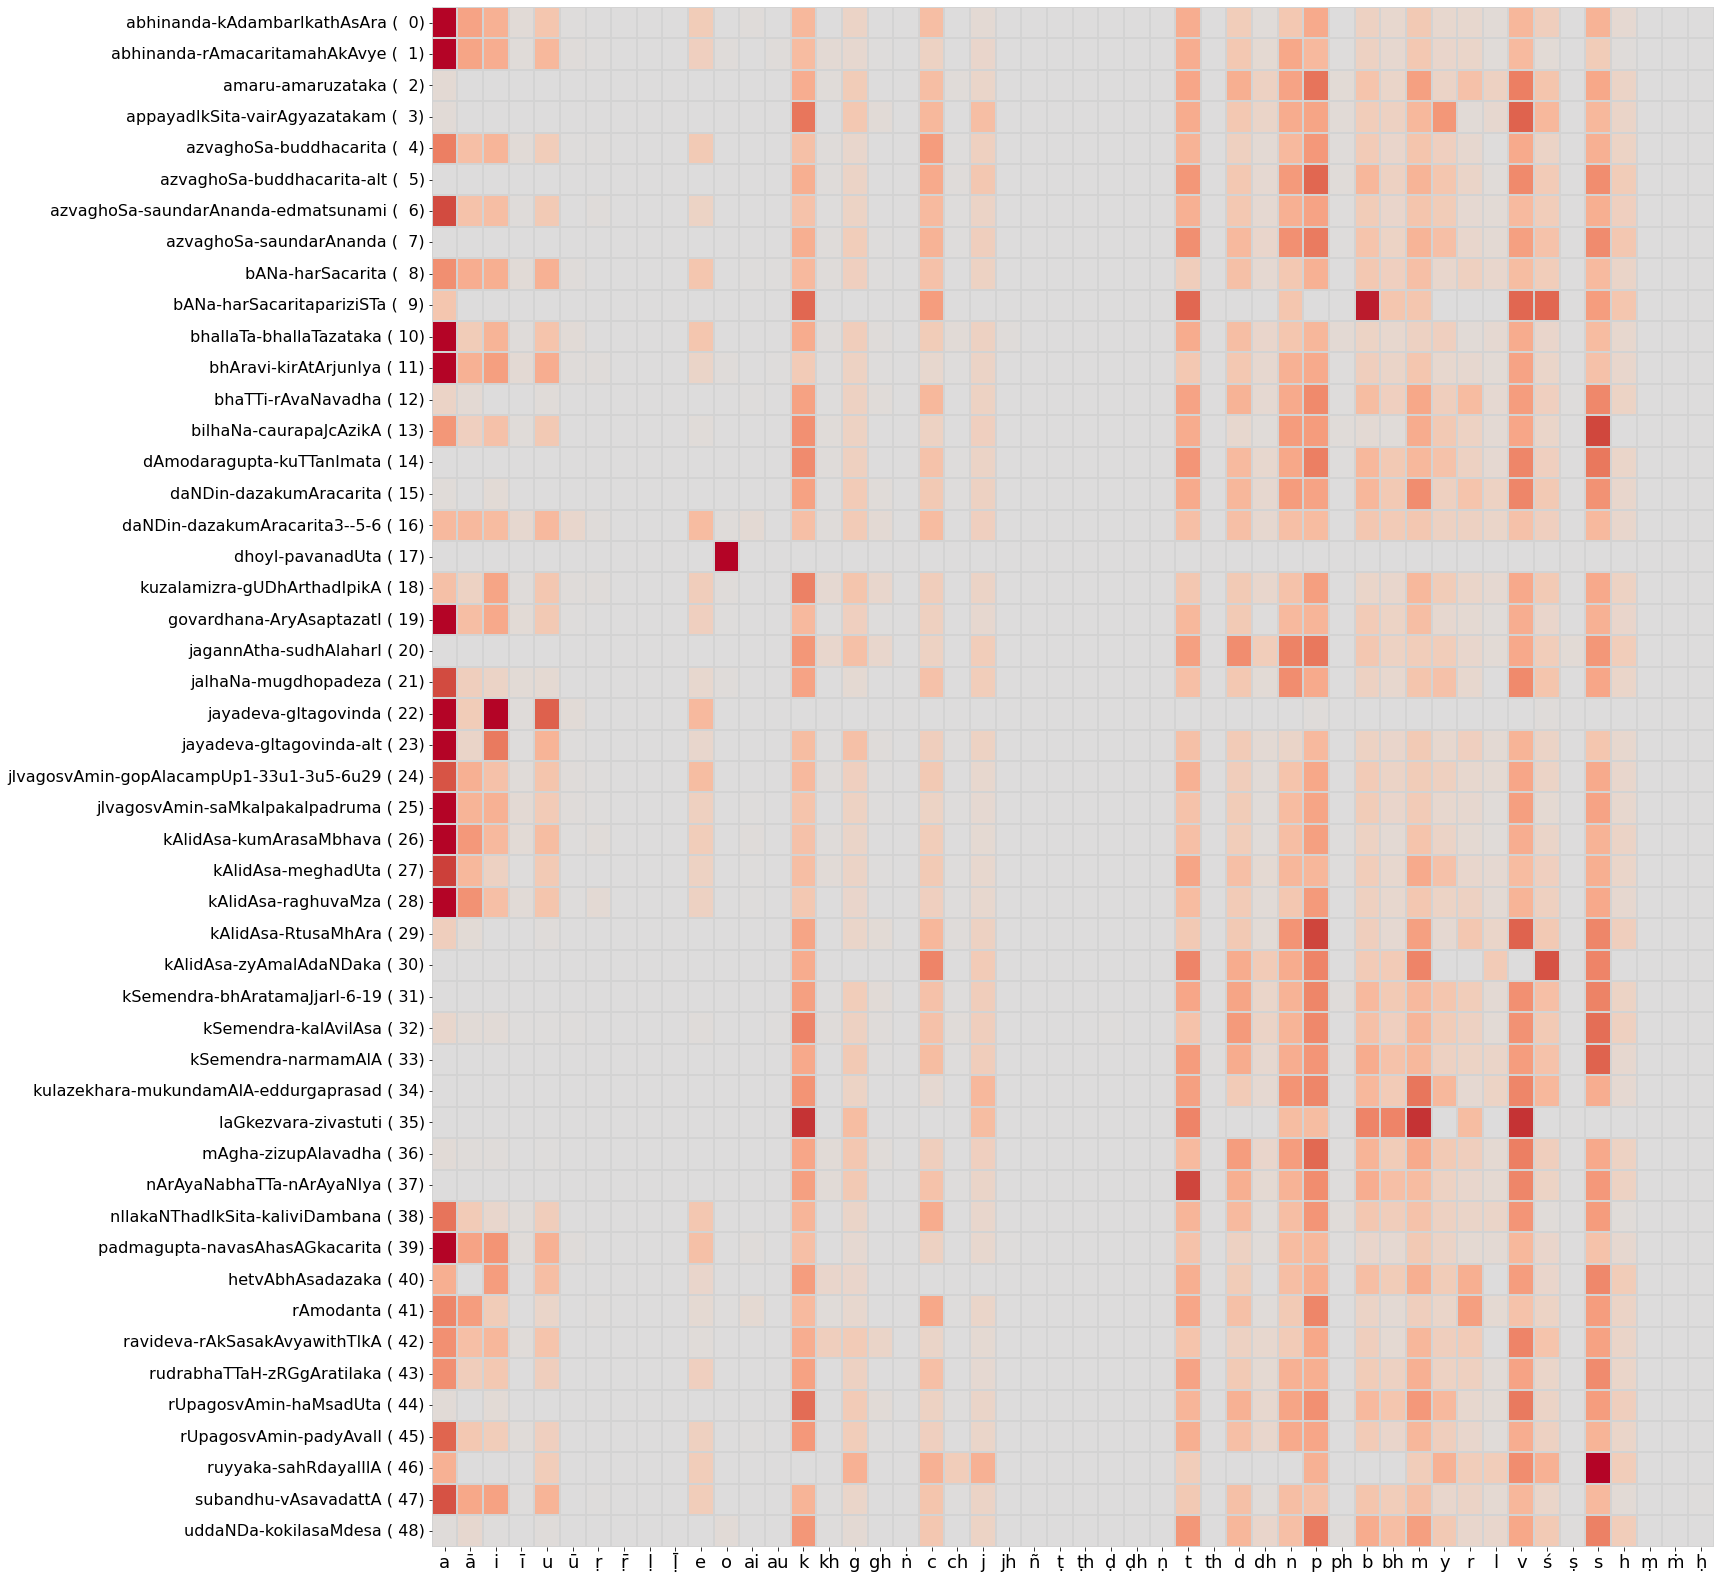

((50, 49), (50, 793))

In [10]:

slice = kavya_gmsound_normalized.iloc[:, :].copy()
# choose columns with kAli or magha or bhAsa or hArs or bhAr case insensitive
# slice = slice.loc[:, slice.columns.str.contains('^(kAli|mAgha|bhAsa|hArs|bhAr|pANi)', case=True, regex=True)]
# drop any column with common substrings
slice = slice.loc[:, ~slice.columns.str.contains('comm', case=False)]
slice = slice.loc[:, ~slice.columns.str.contains('1-6', case=False)]
slice = slice.loc[:, ~slice.columns.str.contains('valla', case=False)]
slice = slice.loc[:, ~slice.columns.str.contains('edkale', case=False)]
slice.columns = [ f"{v} ({ix:3d})" for ix, v  in enumerate(slice.columns.astype(str)) ]
# plot_transposed_heatmap(slice, figsize=(24, .2*slice.shape[1]), cmap='coolwarm', center=0, cbar=False, annot=True, fmt=".2f")
slice = clip_outliers(slice, 1, 99.5)
plot_transposed_heatmap(slice, figsize=(24, .45*slice.shape[1]), cmap='coolwarm', center=0, cbar=False, annot=True, fmt=".2f")

slice.shape, gmsound_normalized.shape


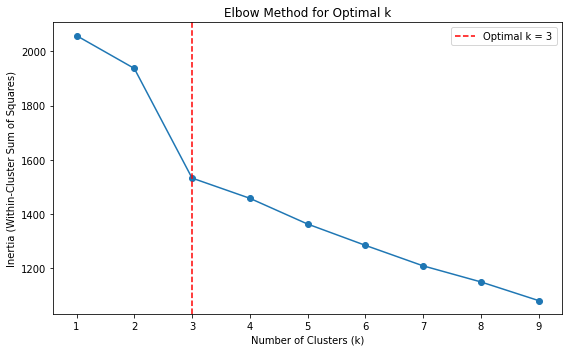

✅ Optimal number of clusters: 3


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_optimal_k(df: pd.DataFrame, k_range=range(1, 11), scale=True, figsize=(8, 5)):
    """
    Plots the elbow curve to help choose the optimal number of clusters using KMeans.

    Parameters:
    - df: pd.DataFrame — rows = sounds, columns = works
    - k_range: range — range of cluster counts to evaluate
    - scale: bool — whether to standardize features
    - figsize: tuple — size of the plot
    """
    X = df.T  # rows = works, columns = sounds

    if scale:
        X_scaled = StandardScaler().fit_transform(X)
    else:
        X_scaled = X.values

    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)

    # Find the elbow point
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(k_range, inertias, marker='o')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
    plt.title("Elbow Method for Optimal k")
    if kl.elbow:
        plt.axvline(x=kl.elbow, color='red', linestyle='--', label=f"Optimal k = {kl.elbow}")
        plt.legend()
    plt.tight_layout()
    plt.show()

    if kl.elbow:
        print(f"✅ Optimal number of clusters: {kl.elbow}")
        return kl.elbow
    else:
        print("⚠️ No clear elbow detected. Consider inspecting silhouette scores.")
        return None

elbow_k = plot_optimal_k(slice, k_range=range(1, 10))



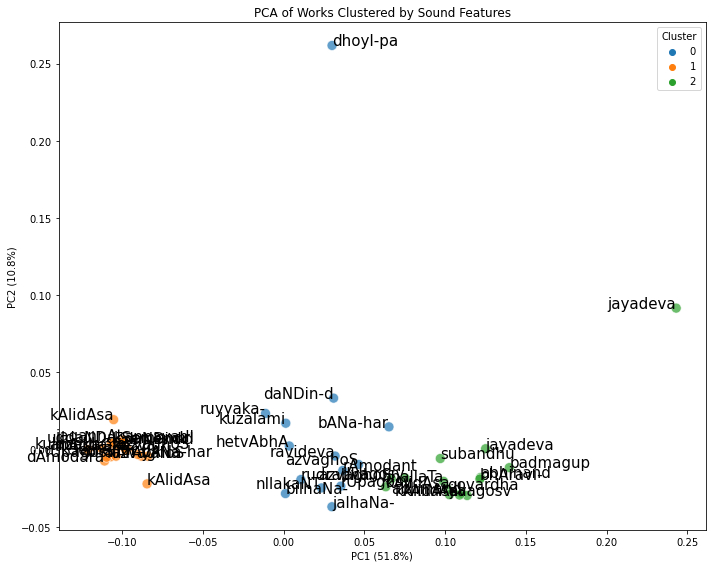


🔍 Top contributing sounds to PC1:
a    0.667888
i    0.341281
u    0.252801
ā    0.251719
k    0.199769
v    0.184770
m    0.175773
p    0.171929
s    0.167794
t    0.162308
dtype: float64

🔍 Top contributing sounds to PC2:
o    0.478574
a    0.463540
v    0.302005
p    0.292570
s    0.256634
n    0.247979
k    0.237688
t    0.235122
ā    0.195672
m    0.169834
dtype: float64


/var/folders/yw/khs2fgqs5d39_5lgfvh8mqlh0000gn/T/ipykernel_8332/3063295173.py:114: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/Users/sunder/miniforge3/envs/tfmetal/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


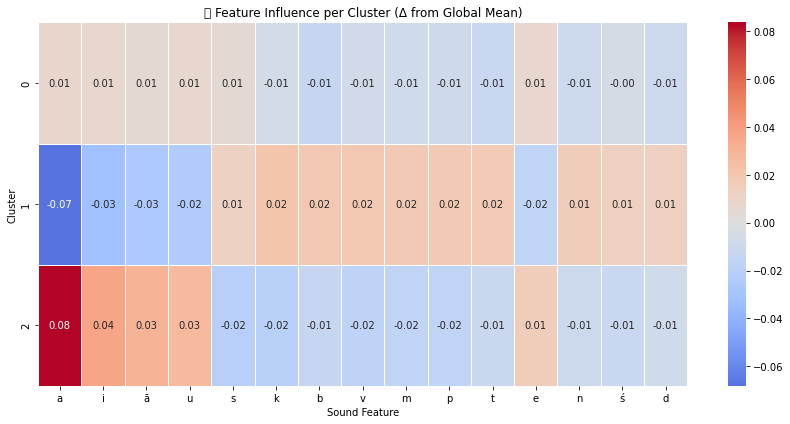


📊 Number of works in each cluster:
Cluster
0    14
1    20
2    15
Name: count, dtype: int64


In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def analyze_and_plot_clusters(
    df: pd.DataFrame,
    n_clusters=4,
    n_components=2,
    scale=False,
    random_state=42,
    figsize=(10, 8)
):
    """
    Performs PCA and KMeans clustering on the transposed DataFrame (works as rows),
    and visualizes clusters in 2D PCA space. Also prints top contributing features (sounds).

    Parameters:
    - df: pd.DataFrame — rows = sounds, columns = works
    - n_clusters: int — number of clusters for KMeans
    - n_components: int — PCA components for visualization
    - scale: bool — whether to standardize features before PCA
    - random_state: int — for reproducibility
    - figsize: tuple — size of the plot
    """
    X = df.T  # Now rows = works, columns = sounds
    works = X.index

    if scale:
        X_scaled = StandardScaler().fit_transform(X)
    else:
        X_scaled = X.values

    # PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    # Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    labels = kmeans.fit_predict(X_pca)

    # Plot
    plt.figure(figsize=figsize)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10', s=100, alpha=0.7,)
    for i, label in enumerate(works):
        jitter = np.random.normal(0, 1.2)*0
        plt.text(X_pca[i, 0], X_pca[i, 1] + jitter, label[:8], fontsize=15, ha=['right', 'left'][i%2], rotation=5*i*0)
    # let the graph be log-scaled
    # plt.xscale('log')
    # plt.yscale('log')   
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA of Works Clustered by Sound Features")
    plt.legend(title="Cluster", loc='best')
    plt.tight_layout()
    plt.show()

    # Top contributing features (loadings)
    loadings = pd.Series(pca.components_[0], index=X.columns)
    top_features = loadings.abs().sort_values(ascending=False).head(10)
    print("\n🔍 Top contributing sounds to PC1:")
    print(top_features)

    loadings = pd.Series(pca.components_[1], index=X.columns)
    top_features = loadings.abs().sort_values(ascending=False).head(10)
    print("\n🔍 Top contributing sounds to PC2:")
    print(top_features)

    # Cluster assignments for each work
    cluster_assignments = pd.Series(labels, index=works, name="Cluster")
    with pd.option_context('display.max_rows', None):
        pass
        # print("\n📁 Cluster assignment for each work:")
        # print(cluster_assignments.sort_values())

    # Map cluster labels back to original data
    X_orig = pd.DataFrame(X_scaled, index=works, columns=X.columns)
    X_orig['Cluster'] = labels

    # Compute mean feature values per cluster
    cluster_means = X_orig.groupby('Cluster').mean()

    # Compute global mean for comparison
    global_mean = X_orig.drop(columns='Cluster').mean()

    # print("\n🎯 Top distinguishing features per cluster:")
    # for cluster_id in range(n_clusters):
    #     diffs = cluster_means.loc[cluster_id] - global_mean
    #     top_features = diffs.abs().sort_values(ascending=False).head(5)
    #     print(f"\nCluster {cluster_id}:")
    #     for feat in top_features.index:
    #         direction = "↑" if diffs[feat] > 0 else "↓"
    #         print(f"  {feat}: {direction} (Δ = {diffs[feat]:.2f})")


    # Compute Δ matrix: difference between cluster means and global mean
    delta_matrix = cluster_means.subtract(global_mean)

    # Optional: focus on top N most varying features across clusters
    top_n = 15
    feature_variability = delta_matrix.abs().max(axis=0)
    top_features = feature_variability.sort_values(ascending=False).head(top_n).index
    delta_top = delta_matrix[top_features]

    # Plot heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(delta_top, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
    plt.title("🔍 Feature Influence per Cluster (Δ from Global Mean)")
    plt.xlabel("Sound Feature")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    # Count of documents per cluster
    cluster_counts = cluster_assignments.value_counts().sort_index()
    print("\n📊 Number of works in each cluster:")
    print(cluster_counts)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

analyze_and_plot_clusters(slice, n_clusters=elbow_k, scale=not True,)#     xfigsize=(30, 20))
# blob:vscode-webview://0k44o6nuahumc3l6lr8ll0k4hndmdp1ge0q6dlofqqkkgvdfk981/2025e797-275a-4b7b-950b-5b305b2b40fc